In [2]:
import numpy as np
from matplotlib import pyplot as plt, cm
from mpl_toolkits.mplot3d import Axes3D
import sys

In [3]:
nx = 65 # Grid Points in X
x_max = 1
x_min = 0

ny = 65 # Grid Points in Y
y_max = 1
y_min = 0


dx = (x_max - x_min) / (nx - 1)
dy = (y_max - y_min) / (ny - 1)


rho = 1 # density
dt = .001 # timestep


u = np.zeros((ny, nx)) #Using NumPy to create zero arrays of order ny nx
v = np.zeros((ny, nx))
p = np.zeros((ny, nx))

x = np.linspace(x_min, x_max, nx)
y = np.linspace(y_min, y_max, ny)
X, Y = np.meshgrid(x,y)

In [4]:
#Boundary Conditions
def set_velocity_boundary(u,v):
  u[-1, :] = 1 #Lid Velocity
  u[0, :]  = 0 #Bottom Velocity
  u[0, :]  = 0
  u[:, 0]  = 0
  u[:, -1] = 0
  v[0, :]  = 0
  v[-1, :] = 0
  v[:, 0]  = 0
  v[:, -1] = 0
  return u,v

In [5]:
#Pressure boundary conditions
def set_pressure_boundary(p):

  p[:, -1] = p[:, -2] # dp/dx = 0 at x = 2
  p[0, :] = p[1, :]   # dp/dy = 0 at y = 0
  p[:, 0] = p[:, 1]   # dp/dx = 0 at x = 0
  # Pressure boundary conditions (Dirichlet or "fixed")
  p[-1, :] = 0        # p = 0 at y = 2

  return p

In [7]:
#Discretization Formulas

def forward_diff_x(f):
    return (f[1:-1, 2:] - f[1:-1, 0:-2]) / (2*dx)

def forward_diff_y(f):
    return (f[2:, 1:-1] - f[0:-2, 1:-1]) / (2*dy)

def backward_diff_x(f):
    return (f[1:-1, 1:-1] - f[1:-1, 0:-2]) / dx

def backward_diff_y(f):
    return (f[1:-1, 1:-1] - f[0:-2, 1:-1]) / dy

def diff_2nd_x(f):
    return (f[1:-1, 0:-2] - 2*f[1:-1, 1:-1] + f[1:-1, 2:]) / dx**2

def diff_2nd_y(f):
    return (f[0:-2, 1:-1] - 2*f[1:-1, 1:-1] + f[2:, 1:-1]) / dy**2

def laplacian(f):
    return diff_2nd_x(f) + diff_2nd_y(f)



# Temporal Discretization

$$\frac{\mathbf{u}^{n+1}-\mathbf{u}^n}{\Delta t}=-\frac{1}{\rho}\nabla p^{n+1} - \mathbf{u}^n \cdot \nabla \mathbf{u}^n + \nu \nabla ^2 \mathbf{u}^n$$

This can be rewritten as:

$$\mathbf{u}^{n+1}=\left( -\frac{1}{\rho}\nabla p^{n+1}  - \mathbf{u}^n \cdot \nabla \mathbf{u}^n + \nu \nabla ^2 \mathbf{u}^n \right)\Delta t + \mathbf{u}^n $$

Which is actually also easy to breakdown ($\frac{\partial u^n}{\partial x}=\frac{u^n(i+1,j)-u^n(i-1,j}{2\Delta x}$):

$$u^{n+1} = \left( - \frac{1}{\rho} \frac{p^{n+1}-p^n}{\Delta x} -\left( u^n \frac{\partial u^n}{\partial x}+ v^n\frac{\partial u^n}{\partial y} \right) + \nu \left(\frac{\partial^2 u^n}{\partial^2 x} + \frac{\partial^2 u^n}{\partial^2 y}\right) \right) \Delta t + u^n$$

$$v^{n+1} = \left( - \frac{1}{\rho} \frac{p^{n+1}-p^n}{\Delta y} -\left( u^n \frac{\partial v^n}{\partial x}+ v^n\frac{\partial v^n}{\partial y} \right) + \nu \left(\frac{\partial^2 v^n}{\partial^2 x} + \frac{\partial^2 v^n}{\partial^2 y}\right) \right) \Delta t + v^n$$

In [6]:
def vel_without_pressure(u, v, nu, dt):
    un = u.copy()
    vn = v.copy()

    u[1:-1, 1:-1] = un[1:-1, 1:-1] + dt * (
        - un[1:-1,1:-1] * forward_diff_x(un)   # central diff advection
        - vn[1:-1,1:-1] * forward_diff_y(un)
        + nu * laplacian(un)
    )

    v[1:-1, 1:-1] = vn[1:-1, 1:-1] + dt * (
        - un[1:-1,1:-1] * forward_diff_x(vn)
        - vn[1:-1,1:-1] * forward_diff_y(vn)
        + nu * laplacian(vn)
    )

    return u, v

 # Pressure Poisson Equation

$$\nabla ^2 p^{n+1} = \frac{\rho}{\Delta t} \nabla \cdot \mathbf{u}^*$$

here's how it continues to break down:

$$\frac{\partial ^2 p^{n+1}}{\partial x^2}+ \frac{\partial ^2 p^{n+1}}{\partial y^2} = \frac{\rho}{\Delta t} \left( \frac{\partial u^*}{\partial x} + \frac{\partial v^*}{\partial y} \right)$$



In [8]:
# To get the RHS of pressure poisson equation
def get_R(u_without_pressure, v_without_pressure, dt):
  divergence_vel_without_pressure = (
      forward_diff_x(u_without_pressure) + forward_diff_y(v_without_pressure)
  )

  b = (rho/dt) * divergence_vel_without_pressure
  return b

then -

$$\frac{\partial ^2 p^{n+1}}{\Delta x^2}+ \frac{\partial ^2 p^{n+1}}{\Delta y^2} = b$$

$$\frac{p^{n+1}(i-1,j) - 2p^{n+1}(i,j) + p^{n+1}(i+1,j)}{\Delta x^2}+ \frac{p^{n+1}(i-1,j) - 2p^{n+1}(i,j) + p^{n+1}(i+1,j)}{\Delta y^2} = b$$

$$\frac{\left(p^{n+1}(i-1,j) - 2p^{n+1}(i,j) + p^{n+1}(i+1,j)\right) \Delta y^2 + \left( p^{n+1}(i-1,j) - 2p^{n+1}(i,j) + p^{n+1}(i+1,j) \right) \Delta x^2}{\Delta x^2 \Delta y^2} = b$$

$$\left(p^{n+1}(i-1,j) - 2p^{n+1}(i,j) + p^{n+1}(i+1,j)\right) \Delta y^2 + \left( p^{n+1}(i-1,j) - 2p^{n+1}(i,j) + p^{n+1}(i+1,j) \right) \Delta x^2 = b^n(i,j) \Delta x^2 \Delta y^2$$

$$p^{n+1}(i-1,j)\Delta y^2 - 2p^{n+1}(i,j)\Delta y^2 + p^{n+1}(i+1,j)\Delta y^2  + p^{n+1}(i-1,j)\Delta x^2 - 2p^{n+1}(i,j)\Delta x^2 + p^{n+1}(i+1,j)\Delta x^2   = b^n(i,j) \Delta x^2 \Delta y^2$$

$$ - 2\left( \Delta y^2 + \Delta x^2 \right) p^{n+1}(i,j)    = - \Delta y^2 \left(p^{n+1}(i-1,j) + p^{n+1}(i+1,j) \right) - \Delta x^2 \left( p^{n+1}(i-1,j) + p^{n+1}(i+1,j) \right) + b^n(i,j) \Delta x^2 \Delta y^2$$

finally
$$ p^{n+1}(i,j)    = \frac{\Delta y^2 \left(p^{n+1}(i-1,j) + p^{n+1}(i+1,j) \right) + \Delta x^2 \left( p^{n+1}(i-1,j) + p^{n+1}(i+1,j) \right) - b^n(i,j) \Delta x^2 \Delta y^2}{2\left( \Delta y^2 + \Delta x^2 \right) }$$

In [9]:
# Solving the pressure poisson equation
def pressure_poisson(p, b, dt, nit=200):
    for _ in range(nit):
        pn = p.copy()
        term1 = (pn[0:-2, 1:-1] + pn[2:, 1:-1]) * dy**2
        term2 = (pn[1:-1, 0:-2] + pn[1:-1, 2:]) * dx**2
        term3 = -(b * (dx**2 * dy**2))
        p[1:-1, 1:-1] = (term1 + term2 + term3) / (2 * (dx**2 + dy**2))
        p = set_pressure_boundary(p)
    return p


# Update velocities: **Corrector step**
Finally, we have the pressure we were missing. Now we can update the velocity from $\mathbf{u}^*$ into $\mathbf{u}^{n+1}$.

$$\mathbf{u}^{n+1}=\Delta t\left( - \frac{1}{\rho}  \nabla p^{n+1}\right) + \mathbf{u}^*$$

which can be broken down as:

$$u^{n+1}=-\frac{\Delta t}{\rho}\left(\frac{\partial p^{n+1}}{\partial x} \right) + u^*$$
$$v^{n+1}=-\frac{\Delta t}{\rho}\left( \frac{\partial p^{n+1}}{\partial y}\right) + v^*$$

In [10]:
def update_velocity(u_star, v_star, p, dt):
    u = u_star.copy()
    v = v_star.copy()
    u[1:-1, 1:-1] = (-dt/rho) * forward_diff_x(p) + u_star[1:-1, 1:-1]
    v[1:-1, 1:-1] = (-dt/rho) * forward_diff_y(p) + v_star[1:-1, 1:-1]
    u, v = set_velocity_boundary(u, v)
    return u, v

In [ ]:
def simulate_cavity_flow(nt, u, v, p, nu, dt):
    for n in range(nt):
        u_old = u.copy()

        u, v = vel_without_pressure(u, v, nu, dt)
        b = get_R(u, v, dt)
        p = pressure_poisson(p, b, dt)
        u, v = update_velocity(u, v, p, dt)

        if n % 500 == 0:
            max_du = np.max(np.abs(u - u_old))
            print(f"  Iter {n:5d}, max du = {max_du:.6f}")

    return u, v, p

In [12]:
# Ghia et al. (1982) Benchmark Data
# Source: Tables 1 & 2, Journal of Computational Physics, 48(3), 387-411

# y-coordinates for u-velocity along vertical centreline (x/L = 0.5)
ghia_y = np.array([0.0000, 0.0547, 0.0625, 0.0703, 0.1016, 0.1719,
                   0.2813, 0.4531, 0.5000, 0.6172, 0.7344, 0.8516,
                   0.9531, 0.9609, 0.9688, 0.9766, 1.0000])

# x-coordinates for v-velocity along horizontal centreline (y/L = 0.5)
ghia_x = np.array([0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563,
                   0.2266, 0.2344, 0.5000, 0.8047, 0.8594, 0.9063,
                   0.9453, 0.9531, 0.9609, 0.9688, 1.0000])

# u-velocity data
ghia_u = {
    100:  np.array([ 0.00000, -0.03717, -0.04192, -0.04775, -0.06434,
                    -0.10150, -0.15662, -0.21090, -0.20581, -0.13641,
                     0.00332,  0.23151,  0.68717,  0.73722,  0.78871,
                     0.84123,  1.00000]),

    400:  np.array([ 0.00000, -0.08186, -0.09266, -0.10338, -0.14612,
                    -0.24299, -0.32726, -0.17119, -0.11477,  0.02135,
                     0.16256,  0.29093,  0.55892,  0.61756,  0.68439,
                     0.75837,  1.00000]),

    1000: np.array([ 0.00000, -0.18109, -0.20196, -0.22220, -0.29730,
                    -0.38289, -0.27805, -0.10648, -0.06080,  0.05702,
                     0.18719,  0.33304,  0.46604,  0.51117,  0.57492,
                     0.65928,  1.00000])
}

# v-velocity data
ghia_v = {
    100:  np.array([ 0.00000,  0.09233,  0.10091,  0.10890,  0.12317,
                     0.16077,  0.17507,  0.17527,  0.05454, -0.24533,
                    -0.22445, -0.16914, -0.10313, -0.08864, -0.07391,
                    -0.05906,  0.00000]),

    400:  np.array([ 0.00000,  0.18719,  0.20591,  0.22371,  0.24869,
                     0.30268,  0.30719,  0.30492,  0.05186, -0.38598,
                    -0.44993, -0.38597, -0.15720, -0.13043, -0.10090,
                    -0.06966,  0.00000]),

    1000: np.array([ 0.00000,  0.27485,  0.29012,  0.30353,  0.32627,
                     0.37095,  0.33075,  0.32235,  0.02526, -0.31966,
                    -0.42665, -0.51550, -0.39188, -0.33714, -0.27669,
                    -0.21388,  0.00000])
}

In [ ]:
def benchmark(u, v, Re):
    y_norm = np.linspace(0, 1, ny)
    x_norm = np.linspace(0, 1, nx)

    u_cl = u[:, nx // 2]   # u along vertical centreline
    v_cl = v[ny // 2, :]   # v along horizontal centreline

    # RMSE
    u_interp = np.interp(ghia_y, y_norm, u_cl)
    v_interp = np.interp(ghia_x, x_norm, v_cl)

    rmse_u = np.sqrt(np.mean((u_interp - ghia_u[Re])**2))
    rmse_v = np.sqrt(np.mean((v_interp - ghia_v[Re])**2))
    max_err_u = np.max(np.abs(u_interp - ghia_u[Re]))
    max_err_v = np.max(np.abs(v_interp - ghia_v[Re]))

    print(f"  RMSE   u: {rmse_u:.4f}  |  v: {rmse_v:.4f}")
    print(f"  MaxErr u: {max_err_u:.4f}  |  v: {max_err_v:.4f}")

    # Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(u_cl, y_norm, 'b-', linewidth=2, label='Present solver')
    ax1.plot(ghia_u[Re], ghia_y, 'ro', markersize=6, label='Ghia et al. (1982)')
    ax1.set_xlabel('u / U_lid')
    ax1.set_ylabel('y / L')
    ax1.set_title(f'U-velocity, vertical centreline (Re={Re})')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(x_norm, v_cl, 'b-', linewidth=2, label='Present solver')
    ax2.plot(ghia_x, ghia_v[Re], 'ro', markersize=6, label='Ghia et al. (1982)')
    ax2.set_xlabel('x / L')
    ax2.set_ylabel('v / U_lid')
    ax2.set_title(f'V-velocity, horizontal centreline (Re={Re})')
    ax2.legend()
    ax2.grid(True)

    plt.suptitle(f'Validation against Ghia et al. (1982) — Re={Re}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'validation_Re{Re}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return rmse_u, rmse_v


Running Re = 100  (nu=0.01, nt=11000, dt=0.001)
  Iter     0, max du = 1.000000
  Iter   500, max du = 0.000399
  Iter  1000, max du = 0.000183
  Iter  1500, max du = 0.000100
  Iter  2000, max du = 0.000062
  Iter  2500, max du = 0.000042
  Iter  3000, max du = 0.000030
  Iter  3500, max du = 0.000022
  Iter  4000, max du = 0.000016
  Iter  4500, max du = 0.000012
  Iter  5000, max du = 0.000009
  Iter  5500, max du = 0.000007
  Iter  6000, max du = 0.000005
  Iter  6500, max du = 0.000004
  Iter  7000, max du = 0.000003
  Iter  7500, max du = 0.000002
  Iter  8000, max du = 0.000002
  Iter  8500, max du = 0.000001
  Iter  9000, max du = 0.000001
  Iter  9500, max du = 0.000001
  Iter 10000, max du = 0.000001
  Iter 10500, max du = 0.000000
  RMSE   u: 0.0146  |  v: 0.0117
  MaxErr u: 0.0288  |  v: 0.0218


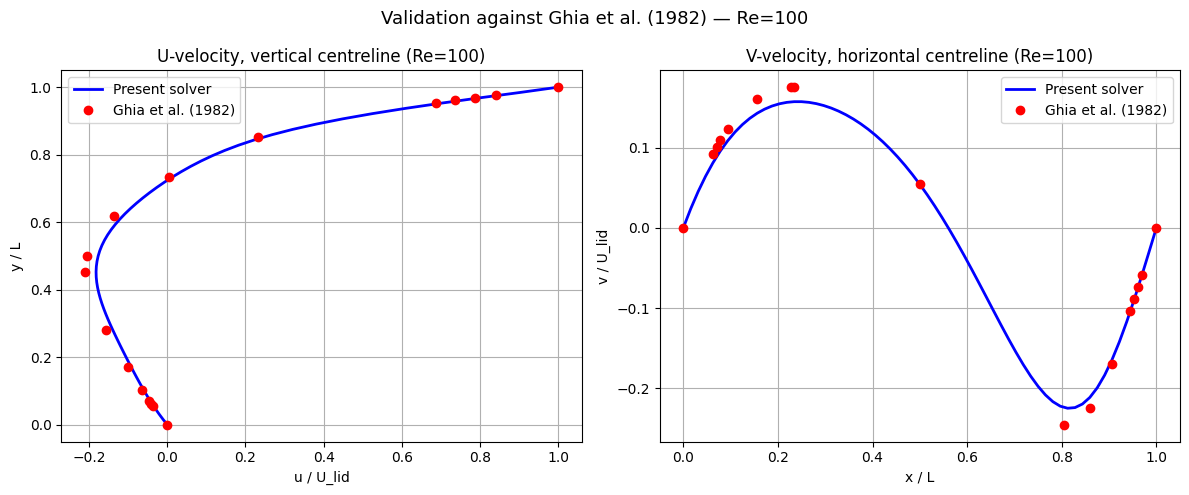


Running Re = 400  (nu=0.0025, nt=30000, dt=0.001)
  Iter     0, max du = 1.000000
  Iter   500, max du = 0.000462
  Iter  1000, max du = 0.000309
  Iter  1500, max du = 0.000207
  Iter  2000, max du = 0.000162
  Iter  2500, max du = 0.000141
  Iter  3000, max du = 0.000116
  Iter  3500, max du = 0.000098
  Iter  4000, max du = 0.000084
  Iter  4500, max du = 0.000072
  Iter  5000, max du = 0.000062
  Iter  5500, max du = 0.000054
  Iter  6000, max du = 0.000047
  Iter  6500, max du = 0.000041
  Iter  7000, max du = 0.000036
  Iter  7500, max du = 0.000032
  Iter  8000, max du = 0.000028
  Iter  8500, max du = 0.000025
  Iter  9000, max du = 0.000022
  Iter  9500, max du = 0.000020
  Iter 10000, max du = 0.000018
  Iter 10500, max du = 0.000016
  Iter 11000, max du = 0.000015
  Iter 11500, max du = 0.000014
  Iter 12000, max du = 0.000012
  Iter 12500, max du = 0.000011
  Iter 13000, max du = 0.000010
  Iter 13500, max du = 0.000009
  Iter 14000, max du = 0.000009
  Iter 14500, max du 

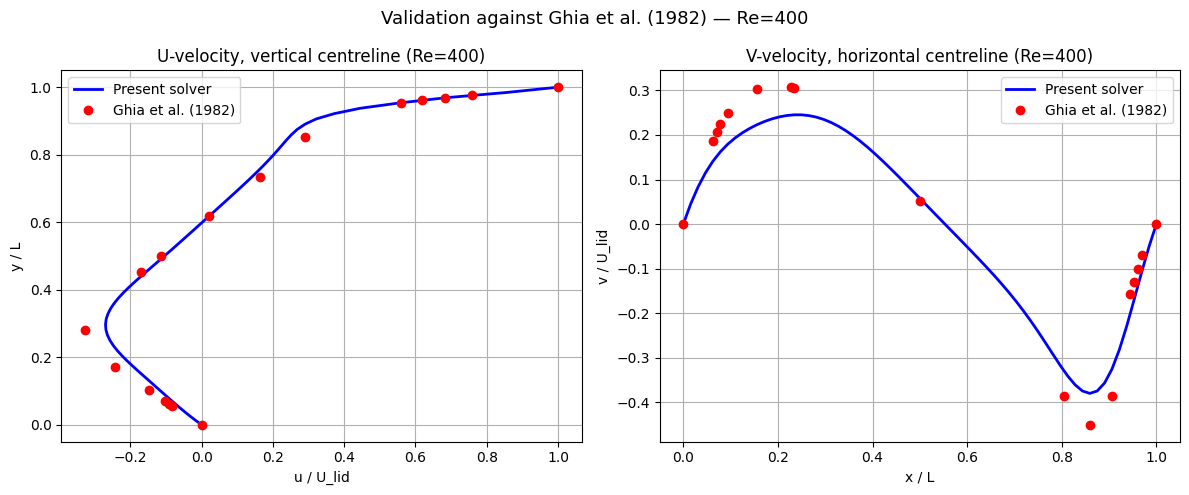


Running Re = 1000  (nu=0.001, nt=50000, dt=0.0005)
  Iter     0, max du = 1.000000
  Iter   500, max du = 0.000512
  Iter  1000, max du = 0.000366
  Iter  1500, max du = 0.000455
  Iter  2000, max du = 0.000447
  Iter  2500, max du = 0.000403
  Iter  3000, max du = 0.000340
  Iter  3500, max du = 0.000276
  Iter  4000, max du = 0.000198
  Iter  4500, max du = 0.000164
  Iter  5000, max du = 0.000179
  Iter  5500, max du = 0.000180
  Iter  6000, max du = 0.000153
  Iter  6500, max du = 0.000137
  Iter  7000, max du = 0.000117
  Iter  7500, max du = 0.000102
  Iter  8000, max du = 0.000091
  Iter  8500, max du = 0.000083
  Iter  9000, max du = 0.000076
  Iter  9500, max du = 0.000069
  Iter 10000, max du = 0.000064
  Iter 10500, max du = 0.000060
  Iter 11000, max du = 0.000056
  Iter 11500, max du = 0.000052
  Iter 12000, max du = 0.000049
  Iter 12500, max du = 0.000046
  Iter 13000, max du = 0.000044
  Iter 13500, max du = 0.000041
  Iter 14000, max du = 0.000040
  Iter 14500, max du

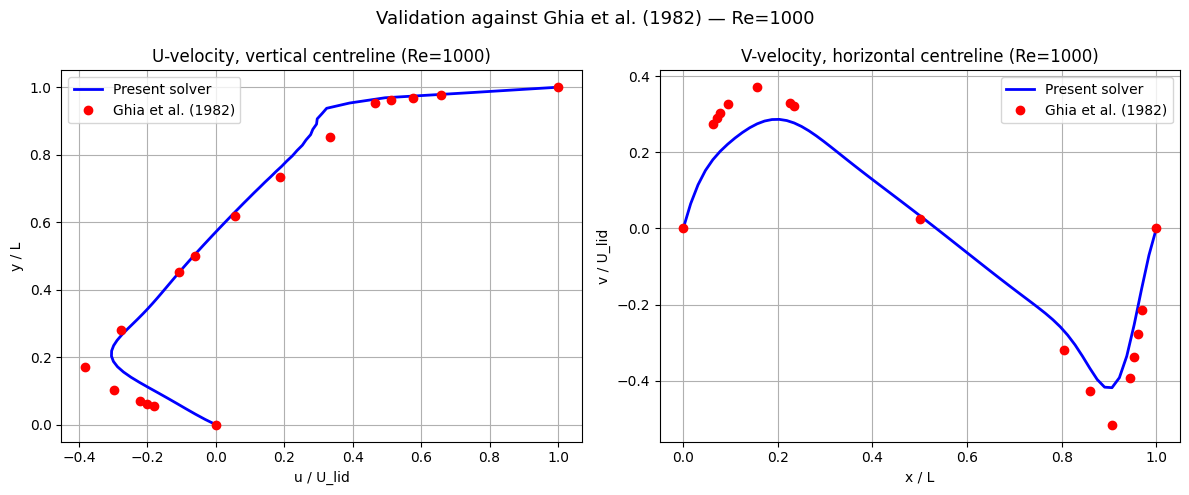


VALIDATION SUMMARY
Re         RMSE u          RMSE v         
----------------------------------------
100        0.0146          0.0117         
400        0.0255          0.0518         
1000       0.0637          0.0743         


In [ ]:
# Configs for each Re
re_configs = {
    100:  {'nu': 0.01,   'nt': 11000, 'dt': 0.001},
    400:  {'nu': 0.0025, 'nt': 30000, 'dt': 0.001},
    1000: {'nu': 0.001,  'nt': 50000, 'dt': 0.0005},
}
results = {}

for Re, config in re_configs.items():
    print(f"\n{'='*50}")
    print(f"Running Re = {Re}  (nu={config['nu']}, nt={config['nt']}, dt={config['dt']})")
    print(f"{'='*50}")

    u = np.zeros((ny, nx))
    v = np.zeros((ny, nx))
    p = np.zeros((ny, nx))

    # Solver
    u, v, p = simulate_cavity_flow(
        nt=config['nt'],
        u=u, v=v, p=p,
        nu=config['nu'],
        dt=config['dt']
    )

    # Benchmark
    rmse_u, rmse_v = benchmark(u, v, Re)
    results[Re] = {'rmse_u': rmse_u, 'rmse_v': rmse_v}

# Summary
print(f"\n{'='*50}")
print(f"VALIDATION SUMMARY")
print(f"{'='*50}")
print(f"{'Re':<10} {'RMSE u':<15} {'RMSE v':<15}")
print(f"{'-'*40}")
for Re, r in results.items():
    print(f"{Re:<10} {r['rmse_u']:<15.4f} {r['rmse_v']:<15.4f}")
print(f"{'='*50}")


Grid refinement: 129×129, Re=1000
nu=0.001, dt=0.00025, nt=80000
  Iter      0, max du = 1.000000
  Iter   2000, max du = 0.000144
  Iter   4000, max du = 0.000096
  Iter   6000, max du = 0.000103
  Iter   8000, max du = 0.000093
  Iter  10000, max du = 0.000083
  Iter  12000, max du = 0.000073
  Iter  14000, max du = 0.000061
  Iter  16000, max du = 0.000050
  Iter  18000, max du = 0.000042
  Iter  20000, max du = 0.000036
  Iter  22000, max du = 0.000031
  Iter  24000, max du = 0.000028
  Iter  26000, max du = 0.000025
  Iter  28000, max du = 0.000022
  Iter  30000, max du = 0.000020
  Iter  32000, max du = 0.000018
  Iter  34000, max du = 0.000016
  Iter  36000, max du = 0.000015
  Iter  38000, max du = 0.000013
  Iter  40000, max du = 0.000012
  Iter  42000, max du = 0.000011
  Iter  44000, max du = 0.000010
  Iter  46000, max du = 0.000010
  Iter  48000, max du = 0.000009
  Iter  50000, max du = 0.000008
  Iter  52000, max du = 0.000008
  Iter  54000, max du = 0.000007
  Iter  56

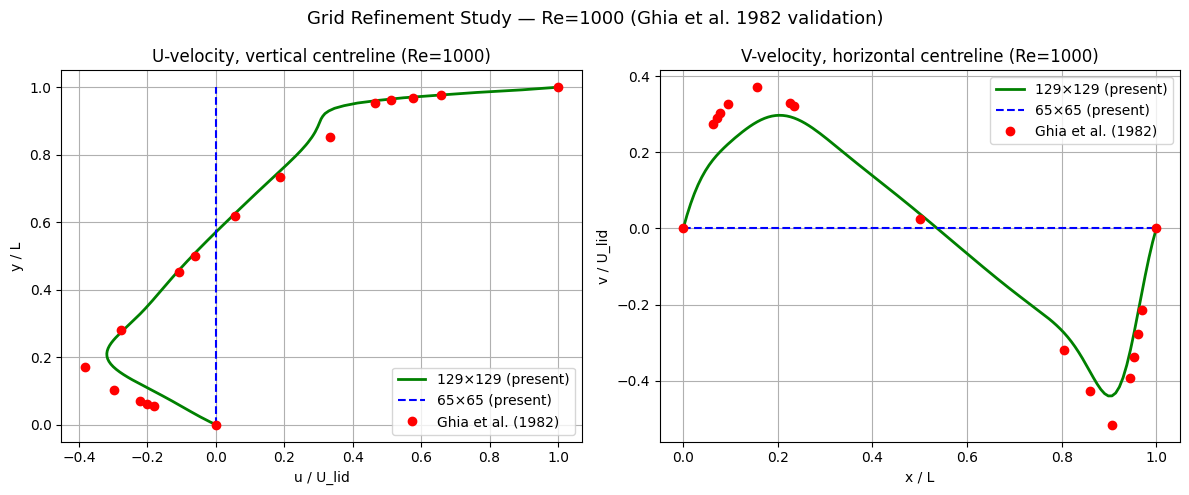

In [13]:
# ── Grid refinement run: 129×129 at Re = 1000 ─────────────────────────────────

# Override grid parameters
nx_fine = 129
ny_fine = 129
dx_fine = 1.0 / (nx_fine - 1)
dy_fine = 1.0 / (ny_fine - 1)

# Fresh fields on fine grid
u_fine = np.zeros((ny_fine, nx_fine))
v_fine = np.zeros((ny_fine, nx_fine))
p_fine = np.zeros((ny_fine, nx_fine))

# Re = 1000 config — halved dt for stability on finer grid
nu_fine = 0.001
dt_fine = 0.00025
nt_fine = 80000

print(f"\n{'='*50}")
print(f"Grid refinement: 129×129, Re=1000")
print(f"nu={nu_fine}, dt={dt_fine}, nt={nt_fine}")
print(f"{'='*50}")

# ── Redefine discretization functions for fine grid ───────────────────────────
def forward_diff_x_f(f):
    return (f[1:-1, 2:] - f[1:-1, 0:-2]) / (2*dx_fine)

def forward_diff_y_f(f):
    return (f[2:, 1:-1] - f[0:-2, 1:-1]) / (2*dy_fine)

def diff_2nd_x_f(f):
    return (f[1:-1, 0:-2] - 2*f[1:-1, 1:-1] + f[1:-1, 2:]) / dx_fine**2

def diff_2nd_y_f(f):
    return (f[0:-2, 1:-1] - 2*f[1:-1, 1:-1] + f[2:, 1:-1]) / dy_fine**2

def laplacian_f(f):
    return diff_2nd_x_f(f) + diff_2nd_y_f(f)

# ── Fine grid solver functions ────────────────────────────────────────────────
def vel_without_pressure_f(u, v, nu, dt):
    un = u.copy()
    vn = v.copy()
    u[1:-1, 1:-1] = un[1:-1, 1:-1] + dt * (
        - un[1:-1,1:-1] * forward_diff_x_f(un)
        - vn[1:-1,1:-1] * forward_diff_y_f(un)
        + nu * laplacian_f(un)
    )
    v[1:-1, 1:-1] = vn[1:-1, 1:-1] + dt * (
        - un[1:-1,1:-1] * forward_diff_x_f(vn)
        - vn[1:-1,1:-1] * forward_diff_y_f(vn)
        + nu * laplacian_f(vn)
    )
    return u, v

def get_R_f(u, v, dt):
    b = (rho/dt) * (forward_diff_x_f(u) + forward_diff_y_f(v))
    return b

def pressure_poisson_f(p, b, dt, nit=200):
    for _ in range(nit):
        pn = p.copy()
        term1 = (pn[0:-2, 1:-1] + pn[2:, 1:-1]) * dy_fine**2
        term2 = (pn[1:-1, 0:-2] + pn[1:-1, 2:]) * dx_fine**2
        term3 = -(b * (dx_fine**2 * dy_fine**2))
        p[1:-1, 1:-1] = (term1 + term2 + term3) / (2*(dx_fine**2 + dy_fine**2))
        p = set_pressure_boundary(p)
    return p

def update_velocity_f(u_star, v_star, p, dt):
    u = u_star.copy()
    v = v_star.copy()
    u[1:-1, 1:-1] = (-dt/rho) * forward_diff_x_f(p) + u_star[1:-1, 1:-1]
    v[1:-1, 1:-1] = (-dt/rho) * forward_diff_y_f(p) + v_star[1:-1, 1:-1]
    u, v = set_velocity_boundary(u, v)
    return u, v

def simulate_fine(nt, u, v, p, nu, dt):
    for n in range(nt):
        u_old = u.copy()
        u, v = vel_without_pressure_f(u, v, nu, dt)
        b = get_R_f(u, v, dt)
        p = pressure_poisson_f(p, b, dt)
        u, v = update_velocity_f(u, v, p, dt)
        if n % 2000 == 0:
            max_du = np.max(np.abs(u - u_old))
            print(f"  Iter {n:6d}, max du = {max_du:.6f}")
    return u, v, p

# ── Run ───────────────────────────────────────────────────────────────────────
u_fine, v_fine, p_fine = simulate_fine(nt_fine, u_fine, v_fine, p_fine, nu_fine, dt_fine)

# ── Benchmark on fine grid ────────────────────────────────────────────────────
y_fine = np.linspace(0, 1, ny_fine)
x_fine = np.linspace(0, 1, nx_fine)

u_cl_fine = u_fine[:, nx_fine // 2]
v_cl_fine = v_fine[ny_fine // 2, :]

u_interp_fine = np.interp(ghia_y, y_fine, u_cl_fine)
v_interp_fine = np.interp(ghia_x, x_fine, v_cl_fine)

rmse_u_fine = np.sqrt(np.mean((u_interp_fine - ghia_u[1000])**2))
rmse_v_fine = np.sqrt(np.mean((v_interp_fine - ghia_v[1000])**2))
max_u_fine  = np.max(np.abs(u_interp_fine - ghia_u[1000]))
max_v_fine  = np.max(np.abs(v_interp_fine - ghia_v[1000]))

print(f"\nRe=1000, 129×129 grid:")
print(f"  RMSE   u: {rmse_u_fine:.4f}  |  v: {rmse_v_fine:.4f}")
print(f"  MaxErr u: {max_u_fine:.4f}  |  v: {max_v_fine:.4f}")

# ── Plot: fine grid vs coarse grid vs Ghia ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# u-velocity
ax1.plot(u_fine[:, nx_fine//2], y_fine, 'g-',  linewidth=2, label='129×129 (present)')
ax1.plot(u[:, nx//2],           y,      'b--', linewidth=1.5, label='65×65 (present)')
ax1.plot(ghia_u[1000], ghia_y, 'ro', markersize=6, label='Ghia et al. (1982)')
ax1.set_xlabel('u / U_lid')
ax1.set_ylabel('y / L')
ax1.set_title('U-velocity, vertical centreline (Re=1000)')
ax1.legend()
ax1.grid(True)

# v-velocity
ax2.plot(x_fine, v_fine[ny_fine//2, :], 'g-',  linewidth=2, label='129×129 (present)')
ax2.plot(x,      v[ny//2, :],           'b--', linewidth=1.5, label='65×65 (present)')
ax2.plot(ghia_x, ghia_v[1000], 'ro', markersize=6, label='Ghia et al. (1982)')
ax2.set_xlabel('x / L')
ax2.set_ylabel('v / U_lid')
ax2.set_title('V-velocity, horizontal centreline (Re=1000)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Grid Refinement Study — Re=1000 (Ghia et al. 1982 validation)', fontsize=13)
plt.tight_layout()
plt.savefig('grid_refinement_Re1000.png', dpi=150, bbox_inches='tight')
plt.show()